In [2]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Try to set style, fall back to default if it fails
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')

# Set visualization parameters
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully!")
print(f"Packages loaded: pandas, numpy, matplotlib, seaborn, plotly")

✅ Libraries imported successfully!
Packages loaded: pandas, numpy, matplotlib, seaborn, plotly


In [3]:
# Generating Sample Dataset

np.random.seed(42)

# Create date range for Q1 2024
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 3, 31)
date_list = [start_date + timedelta(days=x) for x in range((end_date - start_date).days + 1)]

# Generate user sessions
n_sessions = 15000

# Create dataset
data = {
    'session_id': range(1, n_sessions + 1),
    'date': np.random.choice(date_list, n_sessions),
    'channel': np.random.choice(
        ['Organic Search', 'Direct', 'Social Media', 'Email', 'Paid Ads'],
        n_sessions,
        p=[0.35, 0.25, 0.20, 0.12, 0.08]
    ),
    'device': np.random.choice(
        ['Desktop', 'Mobile', 'Tablet'],
        n_sessions,
        p=[0.55, 0.40, 0.05]
    ),
    'country': np.random.choice(
        ['USA', 'UK', 'Canada', 'Australia', 'Germany', 'Other'],
        n_sessions,
        p=[0.45, 0.15, 0.10, 0.08, 0.07, 0.15]
    ),
    'session_duration': np.random.exponential(300, n_sessions),
    'pages_viewed': np.random.poisson(4, n_sessions),
    'added_to_cart': np.random.choice([0, 1], n_sessions, p=[0.68, 0.32]),
    'purchased': np.random.choice([0, 1], n_sessions, p=[0.82, 0.18])
}

df = pd.DataFrame(data)

# Data cleaning
df['session_duration'] = df['session_duration'].clip(upper=3600)  # Cap at 1 hour
df['pages_viewed'] = df['pages_viewed'].clip(upper=20)  # Cap at 20 pages
df['date'] = pd.to_datetime(df['date'])

# Add funnel stage
df['funnel_stage'] = 'Visitor'
df.loc[df['added_to_cart'] == 1, 'funnel_stage'] = 'Lead'
df.loc[df['purchased'] == 1, 'funnel_stage'] = 'Customer'

print(f"✅ Dataset created successfully!")
print(f"Total sessions: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nFirst 5 rows:")
df.head()

✅ Dataset created successfully!
Total sessions: 15,000
Date range: 2024-01-01 to 2024-03-31

First 5 rows:


,session_id,date,channel,device,country,session_duration,pages_viewed,added_to_cart,purchased,funnel_stage
0,1,2024-02-21,Direct,Desktop,USA,449.276388,1,0,0,Visitor
1,2,2024-01-15,Social Media,Desktop,UK,524.230646,2,1,0,Lead
2,3,2024-03-12,Email,Desktop,Canada,107.555345,5,0,0,Visitor
3,4,2024-03-01,Direct,Desktop,USA,306.766171,2,1,0,Lead
4,5,2024-01-21,Direct,Mobile,USA,280.499879,6,0,0,Visitor


In [4]:
# Data Overview and Quality Check
print("**DATASET OVERVIEW**")
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nBasic statistics:")
df.describe()

**DATASET OVERVIEW**
Shape: (15000, 10)

Missing values:
session_id          0
date                0
channel             0
device              0
country             0
session_duration    0
pages_viewed        0
added_to_cart       0
purchased           0
funnel_stage        0
dtype: int64

Data types:
session_id                   int64
date                datetime64[ns]
channel                     object
device                      object
country                     object
session_duration           float64
pages_viewed                 int32
added_to_cart                int64
purchased                    int64
funnel_stage                object
dtype: object

Basic statistics:


,session_id,date,session_duration,pages_viewed,added_to_cart,purchased
count,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,2024-02-15 02:00:23.040000,298.942627,3.994133,0.325467,0.179533
min,1.000000,2024-01-01 00:00:00,0.002530,0.000000,0.000000,0.000000
25%,3750.750000,2024-01-23 00:00:00,87.620844,3.000000,0.000000,0.000000
50%,7500.500000,2024-02-15 00:00:00,208.640676,4.000000,0.000000,0.000000
75%,11250.250000,2024-03-09 00:00:00,418.818685,5.000000,1.000000,0.000000
max,15000.000000,2024-03-31 00:00:00,2914.833864,16.000000,1.000000,1.000000
std,4330.271354,NaN,296.329037,2.000291,0.468565,0.383811


In [5]:
# Calculating Funnel Metrics
total_visitors = len(df)
total_leads = df['added_to_cart'].sum()
total_customers = df['purchased'].sum()

visitor_to_lead_rate = (total_leads / total_visitors) * 100
lead_to_customer_rate = (total_customers / total_leads) * 100 if total_leads > 0 else 0
overall_conversion = (total_customers / total_visitors) * 100

# Drop-off calculations
dropoff_visitor_to_lead = ((total_visitors - total_leads) / total_visitors) * 100
dropoff_lead_to_customer = ((total_leads - total_customers) / total_leads) * 100 if total_leads > 0 else 0

print("="*60)
print("**FUNNEL METRICS SUMMARY**")
print("="*60)
print(f"Total Visitors (Sessions):     {total_visitors:>8,}")
print(f"Total Leads (Added to Cart):   {total_leads:>8,}")
print(f"Total Customers (Purchased):   {total_customers:>8,}")
print("\n" + "-"*60)
print(f"Visitor → Lead Rate:           {visitor_to_lead_rate:>7.2f}%")
print(f"Lead → Customer Rate:          {lead_to_customer_rate:>7.2f}%")
print(f"Overall Conversion Rate:       {overall_conversion:>7.2f}%")
print("\n" + "-"*60)
print(f"Drop-off (Visitor → Lead):     {dropoff_visitor_to_lead:>7.2f}%")
print(f"Drop-off (Lead → Customer):    {dropoff_lead_to_customer:>7.2f}%")
print("="*60)

**FUNNEL METRICS SUMMARY**
Total Visitors (Sessions):       15,000
Total Leads (Added to Cart):      4,882
Total Customers (Purchased):      2,693

------------------------------------------------------------
Visitor → Lead Rate:             32.55%
Lead → Customer Rate:            55.16%
Overall Conversion Rate:         17.95%

------------------------------------------------------------
Drop-off (Visitor → Lead):       67.45%
Drop-off (Lead → Customer):      44.84%


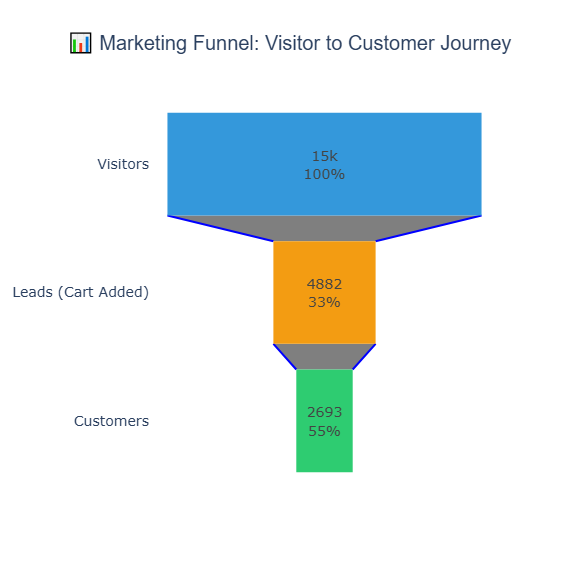

In [7]:
# Interactive Funnel Visualization
fig = go.Figure(go.Funnel(
    y=["Visitors", "Leads (Cart Added)", "Customers"],
    x=[total_visitors, total_leads, total_customers],
    textposition="inside",
    textinfo="value+percent previous",
    marker={"color": ["#3498db", "#f39c12", "#2ecc71"]},
    connector={"line": {"color": "blue", "width": 2, "dash": "solid"}}
))

fig.update_layout(
    title={
        'text': "📊 Marketing Funnel: Visitor to Customer Journey",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20, 'family': 'Arial'}
    },
    font=dict(size=14),
    width=900,
    height=550,
    showlegend=False,
    plot_bgcolor='white'
)

fig.show()

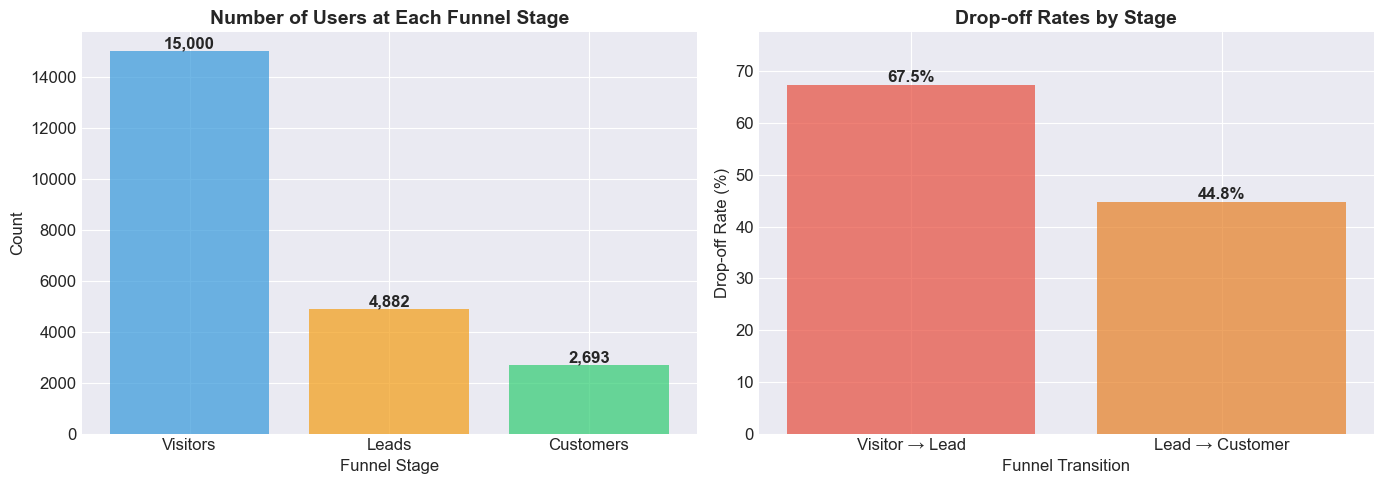


**Key Insight:**
 The biggest drop-off occurs at the Visitor → Lead stage (67.5% loss).
   Focus on improving initial engagement and adding items to cart.


In [8]:
# Drop-off Analysis Visualization
stages = ['Visitors', 'Leads', 'Customers']
counts = [total_visitors, total_leads, total_customers]
dropoffs = [0, dropoff_visitor_to_lead, dropoff_lead_to_customer]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for counts
bars = ax1.bar(stages, counts, color=['#3498db', '#f39c12', '#2ecc71'], alpha=0.7)
ax1.set_title('Number of Users at Each Funnel Stage', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_xlabel('Funnel Stage')
# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Drop-off percentages
dropoff_labels = ['Visitor → Lead', 'Lead → Customer']
dropoff_values = [dropoff_visitor_to_lead, dropoff_lead_to_customer]
colors = ['#e74c3c', '#e67e22']
bars2 = ax2.bar(dropoff_labels, dropoff_values, color=colors, alpha=0.7)
ax2.set_title('Drop-off Rates by Stage', fontsize=14, fontweight='bold')
ax2.set_ylabel('Drop-off Rate (%)')
ax2.set_xlabel('Funnel Transition')
# Add value labels
for bar, value in zip(bars2, dropoff_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.set_ylim(0, max(dropoff_values) * 1.15)

plt.tight_layout()
plt.show()

# Insight
print("\n**Key Insight:**")
if dropoff_visitor_to_lead > dropoff_lead_to_customer:
    print(f" The biggest drop-off occurs at the Visitor → Lead stage ({dropoff_visitor_to_lead:.1f}% loss).")
    print("   Focus on improving initial engagement and adding items to cart.")
else:
    print(f" The biggest drop-off occurs at the Lead → Customer stage ({dropoff_lead_to_customer:.1f}% loss).")
    print("   Focus on cart abandonment recovery and checkout optimization.")

In [9]:
# Channel Metrics Calculation
channel_metrics = df.groupby('channel').agg ({
    'session_id': 'count',
    'added_to_cart': 'sum',
    'purchased': 'sum',
    'session_duration': 'mean',
    'pages_viewed': 'mean'
}).round(2)

channel_metrics.columns = ['visitors', 'leads', 'customers', 'avg_duration_sec', 'avg_pages']
channel_metrics['visitor_to_lead_%'] = (channel_metrics['leads'] / channel_metrics['visitors']) * 100
channel_metrics['lead_to_customer_%'] = (channel_metrics['customers'] / channel_metrics['leads']) * 100
channel_metrics['overall_conversion_%'] = (channel_metrics['customers'] / channel_metrics['visitors']) * 100
channel_metrics = channel_metrics.sort_values('overall_conversion_%', ascending=False)

print(" **CHANNEL PERFORMANCE ANALYSIS**")
print("="*80)
print(channel_metrics.to_string())
print("="*80)

 **CHANNEL PERFORMANCE ANALYSIS**
                visitors  leads  customers  avg_duration_sec  avg_pages  visitor_to_lead_%  lead_to_customer_%  overall_conversion_%
channel                                                                                                                             
Email               1789    595        343            308.11       3.97          33.258804           57.647059             19.172722
Social Media        3068    944        560            305.74       3.98          30.769231           59.322034             18.252934
Organic Search      5114   1668        925            294.12       3.99          32.616347           55.455635             18.087603
Paid Ads            1267    443        220            300.84       4.08          34.964483           49.661400             17.363852
Direct              3762   1232        645            294.95       3.99          32.748538           52.353896             17.145136


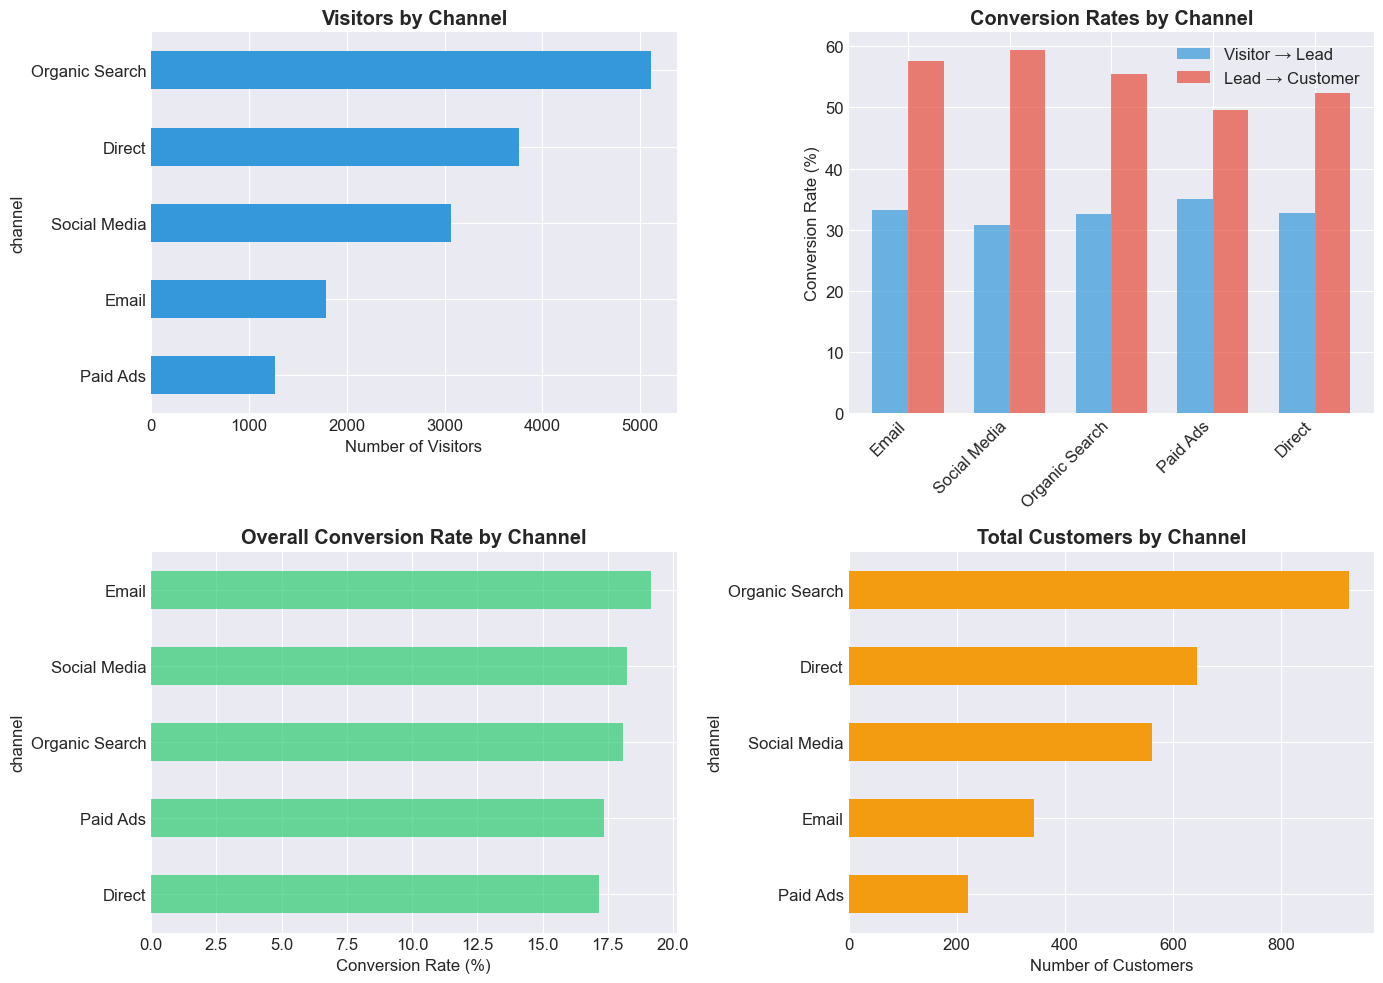

In [10]:
# Channel Performance Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Visitors by Channel
channel_metrics['visitors'].sort_values().plot(kind='barh', ax=axes[0,0], color='#3498db')
axes[0,0].set_title('Visitors by Channel', fontweight='bold')
axes[0,0].set_xlabel('Number of Visitors')

# 2. Conversion Rates by Channel
x = range(len(channel_metrics))
width = 0.35
axes[0,1].bar([i - width/2 for i in x], channel_metrics['visitor_to_lead_%'], 
              width, label='Visitor → Lead', color='#3498db', alpha=0.7)
axes[0,1].bar([i + width/2 for i in x], channel_metrics['lead_to_customer_%'], 
              width, label='Lead → Customer', color='#e74c3c', alpha=0.7)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(channel_metrics.index, rotation=45, ha='right')
axes[0,1].set_ylabel('Conversion Rate (%)')
axes[0,1].set_title('Conversion Rates by Channel', fontweight='bold')
axes[0,1].legend()

# 3. Overall Conversion by Channel
channel_metrics['overall_conversion_%'].sort_values().plot(kind='barh', ax=axes[1,0], 
                                                            color='#2ecc71', alpha=0.7)
axes[1,0].set_title('Overall Conversion Rate by Channel', fontweight='bold')
axes[1,0].set_xlabel('Conversion Rate (%)')

# 4. Customers by Channel
channel_metrics['customers'].sort_values().plot(kind='barh', ax=axes[1,1], color='#f39c12')
axes[1,1].set_title('Total Customers by Channel', fontweight='bold')
axes[1,1].set_xlabel('Number of Customers')

plt.tight_layout()
plt.show()

In [11]:
# ChannelAnalysis
print(" **CHANNEL ROI ANALYSIS**")
print("-"*60)
print("Based on conversion performance, here are the channel optimization recommendations:")

best_channel = channel_metrics.index[0]
worst_channel = channel_metrics.index[-1]
highest_traffic = channel_metrics['visitors'].idxmax()

print(f"\n **TOP PERFORMER:** {best_channel}")
print(f"   • Conversion Rate: {channel_metrics.loc[best_channel, 'overall_conversion_%']:.1f}%")
print(f"   • Leads Generated: {channel_metrics.loc[best_channel, 'leads']:.0f}")
print(f"   • Customers: {channel_metrics.loc[best_channel, 'customers']:.0f}")
print(f"   → Recommendation: Increase budget allocation by 20-30%")

print(f"\n  **LOWEST PERFORMER:** {worst_channel}")
print(f"   • Conversion Rate: {channel_metrics.loc[worst_channel, 'overall_conversion_%']:.1f}%")
print(f"   • Visitors: {channel_metrics.loc[worst_channel, 'visitors']:.0f}")
print(f"   → Recommendation: Audit campaign messaging, landing pages, and targeting")

print(f"\n  **HIGHEST TRAFFIC:** {highest_traffic}")
print(f"   • Visitors: {channel_metrics.loc[highest_traffic, 'visitors']:.0f}")
print(f"   • Conversion Rate: {channel_metrics.loc[highest_traffic, 'overall_conversion_%']:.1f}%")
print(f"   → Recommendation: A/B test to improve conversion efficiency")

 **CHANNEL ROI ANALYSIS**
------------------------------------------------------------
Based on conversion performance, here are the channel optimization recommendations:

 **TOP PERFORMER:** Email
   • Conversion Rate: 19.2%
   • Leads Generated: 595
   • Customers: 343
   → Recommendation: Increase budget allocation by 20-30%

  **LOWEST PERFORMER:** Direct
   • Conversion Rate: 17.1%
   • Visitors: 3762
   → Recommendation: Audit campaign messaging, landing pages, and targeting

  **HIGHEST TRAFFIC:** Organic Search
   • Visitors: 5114
   • Conversion Rate: 18.1%
   → Recommendation: A/B test to improve conversion efficiency


 **DEVICE PERFORMANCE ANALYSIS**
         visitors  leads  customers  avg_duration_sec  avg_pages  visitor_to_lead_%  lead_to_customer_%  overall_conversion_%
device                                                                                                                       
Desktop      8273   2720       1498            300.48       3.97          32.878037           55.073529             18.107095
Mobile       5999   1915       1085            298.37       4.02          31.921987           56.657963             18.086348
Tablet        728    247        110            286.19       4.03          33.928571           44.534413             15.109890


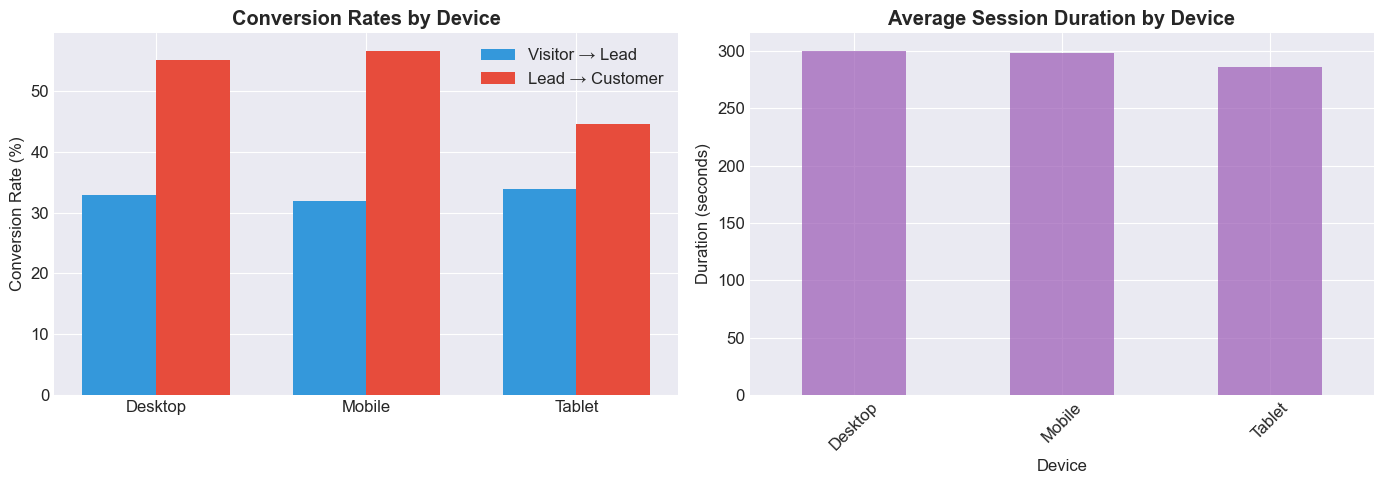

In [12]:
# Device Performance
device_metrics = df.groupby('device').agg ({
    'session_id': 'count',
    'added_to_cart': 'sum',
    'purchased': 'sum',
    'session_duration': 'mean',
    'pages_viewed': 'mean'
}).round(2)

device_metrics.columns = ['visitors', 'leads', 'customers', 'avg_duration_sec', 'avg_pages']
device_metrics['visitor_to_lead_%'] = (device_metrics['leads'] / device_metrics['visitors']) * 100
device_metrics['lead_to_customer_%'] = (device_metrics['customers'] / device_metrics['leads']) * 100
device_metrics['overall_conversion_%'] = (device_metrics['customers'] / device_metrics['visitors']) * 100

print(" **DEVICE PERFORMANCE ANALYSIS**")
print("="*80)
print(device_metrics.to_string())
print("="*80)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conversion rates by device
devices = device_metrics.index
x = range(len(devices))
width = 0.35

axes[0].bar([i - width/2 for i in x], device_metrics['visitor_to_lead_%'], 
            width, label='Visitor → Lead', color='#3498db')
axes[0].bar([i + width/2 for i in x], device_metrics['lead_to_customer_%'], 
            width, label='Lead → Customer', color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(devices)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Conversion Rates by Device', fontweight='bold')
axes[0].legend()

# Session duration by device
device_metrics['avg_duration_sec'].plot(kind='bar', ax=axes[1], color='#9b59b6', alpha=0.7)
axes[1].set_title('Average Session Duration by Device', fontweight='bold')
axes[1].set_ylabel('Duration (seconds)')
axes[1].set_xlabel('Device')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

🌍 **GEOGRAPHIC PERFORMANCE**
           visitors  customers  leads  conversion_rate_%
country                                                 
Other          2251        436    724          19.369169
Australia      1184        223    386          18.834459
USA            6779       1221   2220          18.011506
Germany        1023        182    340          17.790811
Canada         1543        270    491          17.498380
UK             2220        361    721          16.261261


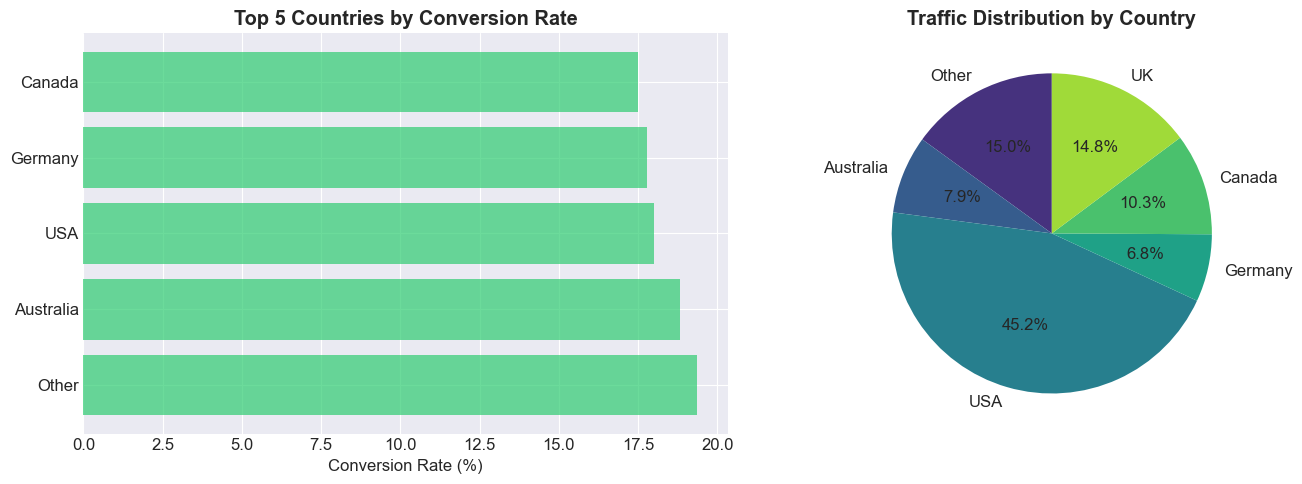

In [13]:
 # Geographic Analysis
country_metrics = df.groupby('country').agg({
    'session_id': 'count',
    'purchased': 'sum',
    'added_to_cart': 'sum'
}).round(2)

country_metrics.columns = ['visitors', 'customers', 'leads']
country_metrics['conversion_rate_%'] = (country_metrics['customers'] / country_metrics['visitors']) * 100
country_metrics = country_metrics.sort_values('conversion_rate_%', ascending=False)

print("🌍 **GEOGRAPHIC PERFORMANCE**")
print("="*70)
print(country_metrics.to_string())
print("="*70)

# Top 5 countries by conversion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conversion rates
top_countries = country_metrics.head(5)
axes[0].barh(top_countries.index, top_countries['conversion_rate_%'], color='#2ecc71', alpha=0.7)
axes[0].set_xlabel('Conversion Rate (%)')
axes[0].set_title('Top 5 Countries by Conversion Rate', fontweight='bold')

# Traffic distribution
country_traffic = country_metrics['visitors'].head(8)
axes[1].pie(country_traffic, labels=country_traffic.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Traffic Distribution by Country', fontweight='bold')

plt.tight_layout()
plt.show()

 **BEHAVIOR PATTERNS BY FUNNEL STAGE**
             session_duration                 pages_viewed             
                         mean  median     std         mean median   std
funnel_stage                                                           
Customer               295.80  211.25  288.31         4.00    4.0  2.03
Lead                   299.77  202.99  296.36         3.96    4.0  1.97
Visitor                299.56  209.70  298.90         4.01    4.0  2.01


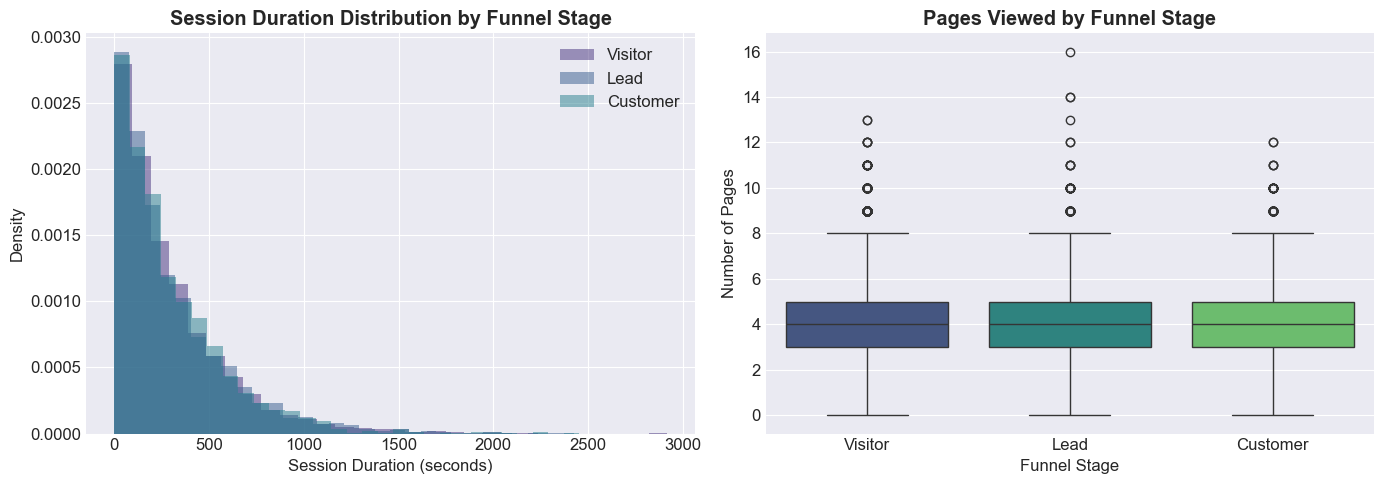

In [14]:
# Behavior Metrics by Funnel Stage
behavior_metrics = df.groupby('funnel_stage').agg({
    'session_duration': ['mean', 'median', 'std'],
    'pages_viewed': ['mean', 'median', 'std']
}).round(2)

print(" **BEHAVIOR PATTERNS BY FUNNEL STAGE**")
print("="*70)
print(behavior_metrics)
print("="*70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Session duration distribution
stages_order = ['Visitor', 'Lead', 'Customer']
for stage in stages_order:
    stage_data = df[df['funnel_stage'] == stage]['session_duration']
    axes[0].hist(stage_data, bins=30, alpha=0.5, label=stage, density=True)
axes[0].set_xlabel('Session Duration (seconds)')
axes[0].set_ylabel('Density')
axes[0].set_title('Session Duration Distribution by Funnel Stage', fontweight='bold')
axes[0].legend()

# Box plot for pages viewed
sns.boxplot(data=df, x='funnel_stage', y='pages_viewed', 
            order=stages_order, ax=axes[1], palette='viridis')
axes[1].set_title('Pages Viewed by Funnel Stage', fontweight='bold')
axes[1].set_xlabel('Funnel Stage')
axes[1].set_ylabel('Number of Pages')

plt.tight_layout()
plt.show()

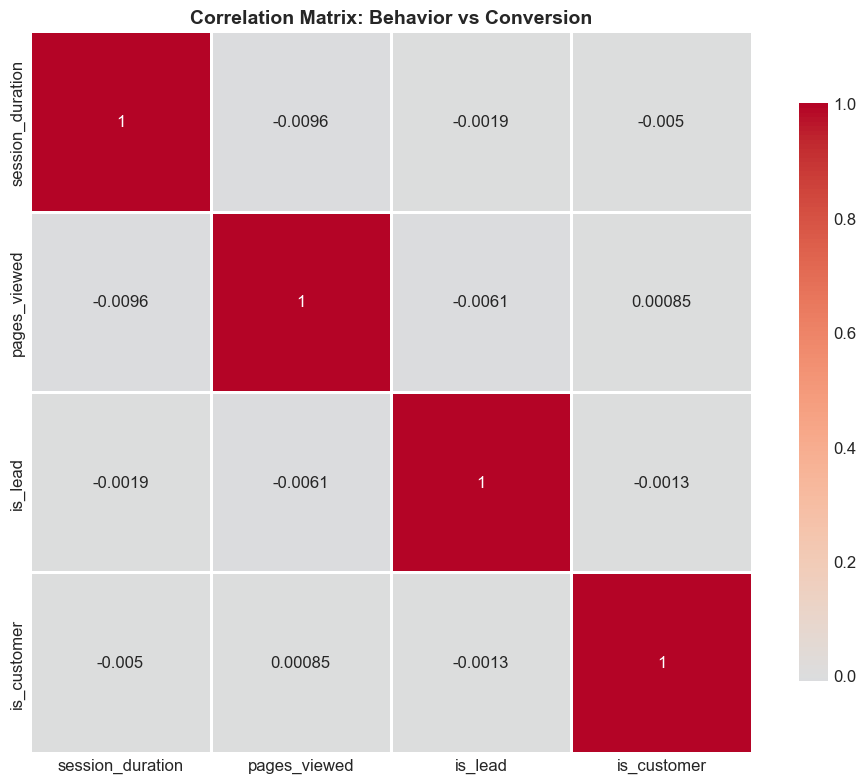


 **CORRELATION INSIGHTS:**
• Pages viewed vs Purchase: 0.001
  → Users who view more pages are more likely to purchase
• Session duration vs Purchase: -0.005
  → Longer sessions correlate with higher purchase likelihood


In [15]:
# Correlation Analysis

df_numeric = df.copy()
df_numeric['is_lead'] = df_numeric['added_to_cart']
df_numeric['is_customer'] = df_numeric['purchased']

# Select numeric columns for correlation
correlation_cols = ['session_duration', 'pages_viewed', 'is_lead', 'is_customer']
correlation_matrix = df_numeric[correlation_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Behavior vs Conversion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n **CORRELATION INSIGHTS:**")
print(f"• Pages viewed vs Purchase: {correlation_matrix.loc['pages_viewed', 'is_customer']:.3f}")
print(f"  → Users who view more pages are more likely to purchase")
print(f"• Session duration vs Purchase: {correlation_matrix.loc['session_duration', 'is_customer']:.3f}")
print(f"  → Longer sessions correlate with higher purchase likelihood")

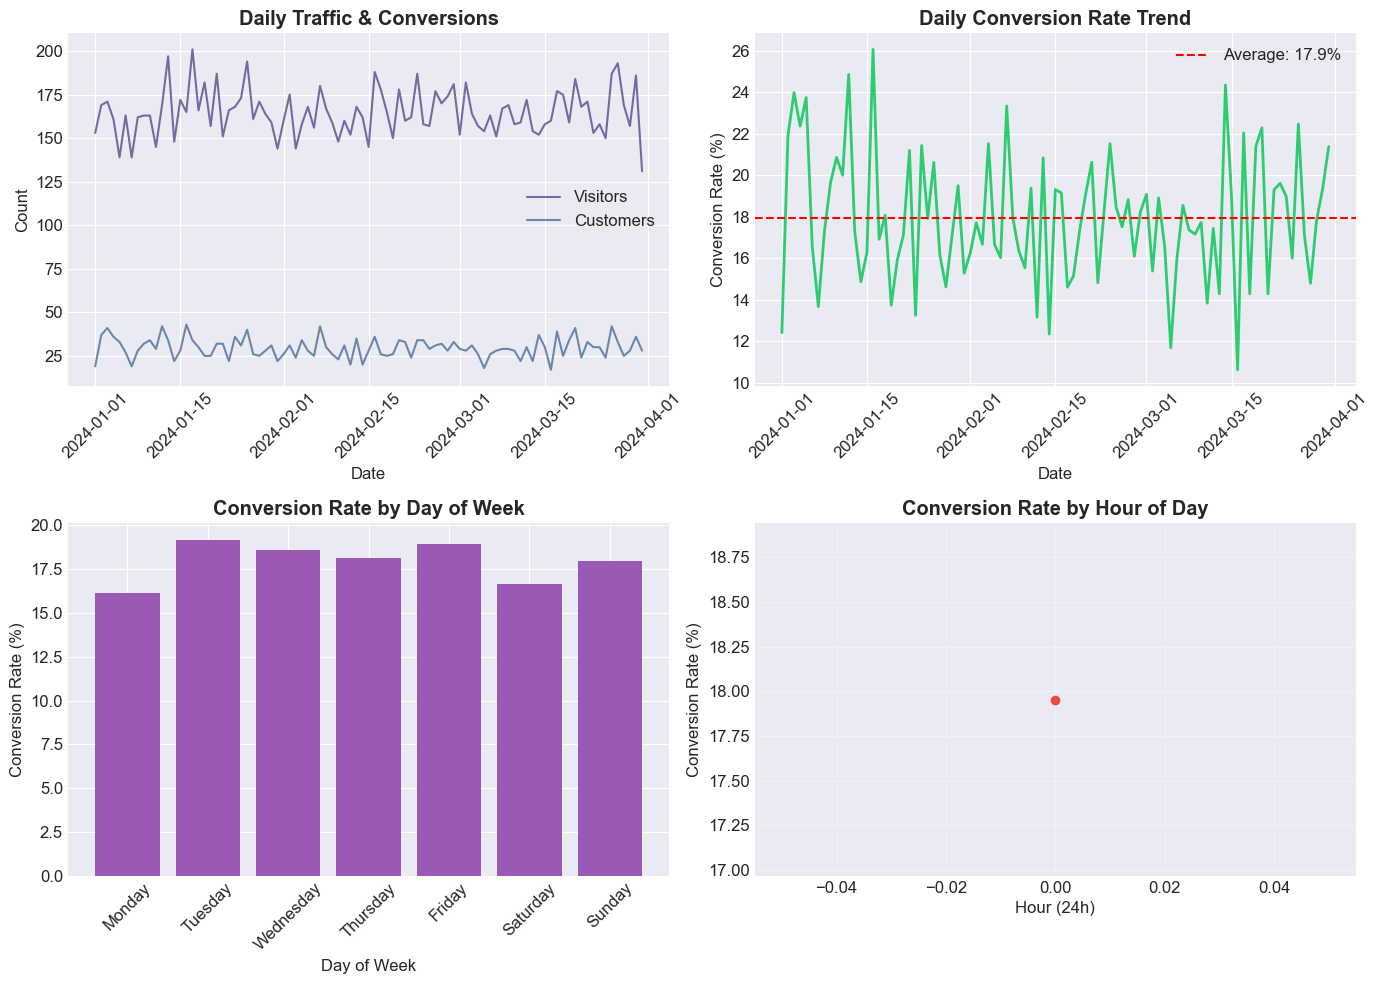


 **TIME-BASED INSIGHTS:**
• Best day for conversion: Tuesday (19.2%)
• Best hour for conversion: 0:00 (18.0%)


In [16]:
# Time-Series Analysis

df['day_of_week'] = df['date'].dt.day_name()
df['hour'] = df['date'].dt.hour
df['week'] = df['date'].dt.isocalendar().week
df['month'] = df['date'].dt.month

# Daily metrics
daily_metrics = df.groupby('date').agg({
    'session_id': 'count',
    'purchased': 'sum',
    'added_to_cart': 'sum'
}).reset_index()
daily_metrics.columns = ['date', 'visitors', 'customers', 'leads']
daily_metrics['conversion_rate'] = (daily_metrics['customers'] / daily_metrics['visitors']) * 100

# Weekly metrics
weekly_metrics = df.groupby('week').agg({
    'session_id': 'count',
    'purchased': 'sum',
    'added_to_cart': 'sum'
}).reset_index()
weekly_metrics.columns = ['week', 'visitors', 'customers', 'leads']
weekly_metrics['conversion_rate'] = (weekly_metrics['customers'] / weekly_metrics['visitors']) * 100

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily visitors and customers
axes[0,0].plot(daily_metrics['date'], daily_metrics['visitors'], label='Visitors', alpha=0.7)
axes[0,0].plot(daily_metrics['date'], daily_metrics['customers'], label='Customers', alpha=0.7)
axes[0,0].set_title('Daily Traffic & Conversions', fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# Daily conversion rate trend
axes[0,1].plot(daily_metrics['date'], daily_metrics['conversion_rate'], 
               color='#2ecc71', linewidth=2)
axes[0,1].axhline(y=daily_metrics['conversion_rate'].mean(), color='red', 
                  linestyle='--', label=f"Average: {daily_metrics['conversion_rate'].mean():.1f}%")
axes[0,1].set_title('Daily Conversion Rate Trend', fontweight='bold')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Conversion Rate (%)')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=45)

# Day of week analysis
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_metrics = df.groupby('day_of_week').agg({
    'session_id': 'count',
    'purchased': 'sum'
}).reindex(dow_order)
dow_metrics['conversion_rate'] = (dow_metrics['purchased'] / dow_metrics['session_id']) * 100

axes[1,0].bar(dow_metrics.index, dow_metrics['conversion_rate'], color='#9b59b6')
axes[1,0].set_title('Conversion Rate by Day of Week', fontweight='bold')
axes[1,0].set_xlabel('Day of Week')
axes[1,0].set_ylabel('Conversion Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Hour of day analysis
hour_metrics = df.groupby('hour').agg({
    'session_id': 'count',
    'purchased': 'sum'
})
hour_metrics['conversion_rate'] = (hour_metrics['purchased'] / hour_metrics['session_id']) * 100

axes[1,1].plot(hour_metrics.index, hour_metrics['conversion_rate'], 
               marker='o', color='#e74c3c', linewidth=2)
axes[1,1].set_title('Conversion Rate by Hour of Day', fontweight='bold')
axes[1,1].set_xlabel('Hour (24h)')
axes[1,1].set_ylabel('Conversion Rate (%)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n **TIME-BASED INSIGHTS:**")
best_day = dow_metrics['conversion_rate'].idxmax()
best_hour = hour_metrics['conversion_rate'].idxmax()
print(f"• Best day for conversion: {best_day} ({dow_metrics.loc[best_day, 'conversion_rate']:.1f}%)")
print(f"• Best hour for conversion: {best_hour}:00 ({hour_metrics.loc[best_hour, 'conversion_rate']:.1f}%)")

In [17]:
# Generating Recommendations
print("="*80)
print(" **ACTIONABLE RECOMMENDATIONS FOR CONVERSION OPTIMIZATION**")
print("="*80)

# Based on funnel analysis
print("\n **FUNNEL OPTIMIZATION**")
print("-"*60)
if dropoff_visitor_to_lead > dropoff_lead_to_customer:
    print(f" Critical Issue: {dropoff_visitor_to_lead:.1f}% drop-off at Visitor → Lead stage")
    print("     Immediate Actions:")
    print("      • Implement exit-intent popups with special offers")
    print("      • A/B test CTA button colors, text, and placement")
    print("      • Add social proof (reviews, testimonials) on landing pages")
    print("      • Simplify the add-to-cart process to 1-click")
else:
    print(f"  Critical Issue: {dropoff_lead_to_customer:.1f}% drop-off at Lead → Customer stage")
    print("    Immediate Actions:")
    print("      • Deploy abandoned cart email sequence (3 emails over 72 hours)")
    print("      • Offer free shipping thresholds or limited-time discounts")
    print("      • Simplify checkout process (reduce form fields)")
    print("      • Add trust badges and payment icons")

# Based on channel analysis
print("\n **CHANNEL STRATEGY**")
print("-"*60)
print(f" High-Performing Channel: {best_channel} ({channel_metrics.loc[best_channel, 'overall_conversion_%']:.1f}% conversion)")
print(f"   → Action: Increase budget by 25-30%, scale successful campaigns")
print(f"\n Underperforming Channel: {worst_channel} ({channel_metrics.loc[worst_channel, 'overall_conversion_%']:.1f}% conversion)")
print(f"   → Action: Audit landing pages, ad copy, and audience targeting")
print(f"\n  High Traffic Channel: {highest_traffic} ({channel_metrics.loc[highest_traffic, 'visitors']:.0f} visitors)")
print(f"   → Action: Run A/B tests to improve conversion efficiency")

# Based on device analysis
print("\n  **DEVICE OPTIMIZATION**")
print("-"*60)
best_device = device_metrics['overall_conversion_%'].idxmax()
print(f"  Best converting device: {best_device} ({device_metrics.loc[best_device, 'overall_conversion_%']:.1f}%)")
print(f"   → Action: Optimize experience for {best_device} users")
if best_device != 'Mobile':
    print(f"  Mobile conversion: {device_metrics.loc['Mobile', 'overall_conversion_%']:.1f}%")
    print(f"   → Action: Conduct mobile usability audit, improve load times")

# Based on behavior
print("\n **BEHAVIOR-BASED OPTIMIZATION**")
print("-"*60)
avg_pages_customers = df[df['purchased']==1]['pages_viewed'].mean()
avg_pages_all = df['pages_viewed'].mean()
print(f" Pages viewed: Customers view {avg_pages_customers:.1f} vs average {avg_pages_all:.1f}")
print(f"   → Action: Implement personalized product recommendations")
print(f" Session duration: Customers spend {df[df['purchased']==1]['session_duration'].mean():.0f} seconds")
print(f"   → Action: Add engaging content (videos, quizzes) to increase time on site")

# Based on time analysis
print("\n  **TIMING OPTIMIZATION**")
print("-"*60)
print(f" Peak conversion day: {best_day} ({dow_metrics.loc[best_day, 'conversion_rate']:.1f}%)")
print(f" Peak conversion hour: {best_hour}:00 ({hour_metrics.loc[best_hour, 'conversion_rate']:.1f}%)")
print(f"   → Action: Schedule email campaigns and ad spend during peak times")

 **ACTIONABLE RECOMMENDATIONS FOR CONVERSION OPTIMIZATION**

 **FUNNEL OPTIMIZATION**
------------------------------------------------------------
 Critical Issue: 67.5% drop-off at Visitor → Lead stage
     Immediate Actions:
      • Implement exit-intent popups with special offers
      • A/B test CTA button colors, text, and placement
      • Add social proof (reviews, testimonials) on landing pages
      • Simplify the add-to-cart process to 1-click

 **CHANNEL STRATEGY**
------------------------------------------------------------
 High-Performing Channel: Email (19.2% conversion)
   → Action: Increase budget by 25-30%, scale successful campaigns

 Underperforming Channel: Direct (17.1% conversion)
   → Action: Audit landing pages, ad copy, and audience targeting

  High Traffic Channel: Organic Search (5114 visitors)
   → Action: Run A/B tests to improve conversion efficiency

  **DEVICE OPTIMIZATION**
------------------------------------------------------------
  Best converting

In [18]:
# Summarizing
print("="*80)
print(" **EXECUTIVE SUMMARY**")
print("="*80)

print("\n **KEY METRICS**")
print(f"• Total Visitors: {total_visitors:,}")
print(f"• Total Customers: {total_customers:,}")
print(f"• Overall Conversion Rate: {overall_conversion:.2f}%")
print(f"• Visitor → Lead Rate: {visitor_to_lead_rate:.2f}%")
print(f"• Lead → Customer Rate: {lead_to_customer_rate:.2f}%")

print("\n **TOP PERFORMERS**")
print(f"• Best Channel: {best_channel} ({channel_metrics.loc[best_channel, 'overall_conversion_%']:.1f}% conversion)")
print(f"• Best Device: {best_device} ({device_metrics.loc[best_device, 'overall_conversion_%']:.1f}% conversion)")
print(f"• Best Day: {best_day}")
print(f"• Best Hour: {best_hour}:00")

print("\n **CRITICAL INSIGHTS**")
if dropoff_visitor_to_lead > dropoff_lead_to_customer:
    print(f"• Primary issue: {dropoff_visitor_to_lead:.1f}% drop-off at initial engagement stage")
else:
    print(f"• Primary issue: {dropoff_lead_to_customer:.1f}% drop-off at checkout stage")
print(f"• {worst_channel} channel underperforming ({channel_metrics.loc[worst_channel, 'overall_conversion_%']:.1f}% conversion)")

print("\n **IMMEDIATE NEXT STEPS (Next 30 Days)**")
print("1. Implement A/B tests for highest drop-off stage")
print("2. Reallocate 25% budget from underperforming to top-performing channels")
print("3. Launch abandoned cart email campaign")
print("4. Optimize mobile experience and page load times")
print("5. Create weekly conversion dashboard for monitoring")

 **EXECUTIVE SUMMARY**

 **KEY METRICS**
• Total Visitors: 15,000
• Total Customers: 2,693
• Overall Conversion Rate: 17.95%
• Visitor → Lead Rate: 32.55%
• Lead → Customer Rate: 55.16%

 **TOP PERFORMERS**
• Best Channel: Email (19.2% conversion)
• Best Device: Desktop (18.1% conversion)
• Best Day: Tuesday
• Best Hour: 0:00

 **CRITICAL INSIGHTS**
• Primary issue: 67.5% drop-off at initial engagement stage
• Direct channel underperforming (17.1% conversion)

 **IMMEDIATE NEXT STEPS (Next 30 Days)**
1. Implement A/B tests for highest drop-off stage
2. Reallocate 25% budget from underperforming to top-performing channels
3. Launch abandoned cart email campaign
4. Optimize mobile experience and page load times
5. Create weekly conversion dashboard for monitoring


In [20]:

# Saving analysis results to CSV files
channel_metrics.to_csv('channel_performance_analysis.csv')
device_metrics.to_csv('device_performance_analysis.csv')
daily_metrics.to_csv('daily_trends.csv')
country_metrics.to_csv('country_analysis.csv')

# Creating summary DataFrame
summary_data = {
    'Metric': [
        'Total Visitors', 'Total Leads', 'Total Customers',
        'Visitor → Lead Rate', 'Lead → Customer Rate', 'Overall Conversion Rate',
        'Top Channel', 'Top Device', 'Best Day', 'Best Hour',
        'Primary Drop-off Stage', 'Drop-off Rate'
    ],
    'Value': [
        f"{total_visitors:,}", f"{total_leads:,}", f"{total_customers:,}",
        f"{visitor_to_lead_rate:.2f}%", f"{lead_to_customer_rate:.2f}%", f"{overall_conversion:.2f}%",
        best_channel, best_device, best_day, f"{best_hour}:00",
        'Visitor → Lead' if dropoff_visitor_to_lead > dropoff_lead_to_customer else 'Lead → Customer',
        f"{max(dropoff_visitor_to_lead, dropoff_lead_to_customer):.1f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('funnel_summary_report.csv', index=False)

print("\n **Analysis Complete!**")
print(" Files exported:")
print("   • channel_performance_analysis.csv")
print("   • device_performance_analysis.csv")
print("   • daily_trends.csv")
print("   • country_analysis.csv")
print("   • funnel_summary_report.csv")
print("\n You're ready to create your dashboard in Power BI/Tableau:)")


 **Analysis Complete!**
 Files exported:
   • channel_performance_analysis.csv
   • device_performance_analysis.csv
   • daily_trends.csv
   • country_analysis.csv
   • funnel_summary_report.csv

 You're ready to create your dashboard in Power BI/Tableau:)
